In [55]:
import duckdb
import pandas as pd
from pathlib import Path
import diskcache
from itertools import chain
from collections import Counter

import igraph as ig
import matplotlib.pyplot as plt
import seaborn.objects as so
import seaborn as sns

from utils.pandas_setup import pandas_setup
pandas_setup()

import pyalex
from pyalex import Works, Authors, Sources, Institutions, Topics, Publishers, Funders
pyalex.config.email = "Lawrence.Cram@anu.edu.au"
pyalex.config.max_retries = 0
pyalex.config.retry_backoff_factor = 0.1
pyalex.config.retry_http_codes = [429, 500, 503]

MY_DATA_PATH = Path('../DATA/')
MY_DATABASE_FILE = Path(MY_DATA_PATH / 'econ.duckdb')
MY_CACHE_FILE = Path('/home/lc/m/.cache/econommicsbusiness/cache.db')
DATAFILES_PATH = Path('../DATAFILES')

In [56]:
class SetUp:

    def __init__(self):
        self._setup_db()
        self._setup_cache()
        return
    
    def _setup_db(self):
        self.db = duckdb.connect(MY_DATABASE_FILE)
        self.db.sql("ATTACH IF NOT EXISTS ':memory:'")
        self.db.sql(""" SET memory_limit = '56GB';
                        SET threads = 6;
                        SET preserve_insertion_order = false;
                        SET order_by_non_integer_literal=true;
                        SET enable_progress_bar = true;
                        SET temp_directory = '/home/lc/m/.tmp';
                    """)
        self.db.sql("SHOW ALL TABLES").show()
        return
    
    def _setup_cache(self):
        self.cache = diskcache.Cache(MY_CACHE_FILE, size_limit=16_000_000_000)
        print(f'{self.cache.check() = }')
        print(f'{self.cache.volume() = }')
        return
    
    def name_of_global_obj(self, obj=None):
        for objname, oid in globals().items():
            if oid is obj:
                return objname
            

In [57]:
class CoauthorshipNetwork(SetUp):

    def __init__(self):
        super().__init__()
        return
    
    def build_authorship_network(self):
        # get works from a few small, top  journals
        source_list = 'https://openalex.org/S2764736659 https://openalex.org/S7397502'
        sql = f"""
                CREATE OR REPLACE TABLE memory.network AS 
                    SELECT replace(source_id, 'https://openalex.org/', '') AS source_id,
                            -- any_value(source_name),
                            replace(institution_id, 'https://openalex.org/', '') AS institution_id,
                            -- any_value(institution_name)
                            count(work_id) AS weight,
                        FROM works w
                        LEFT JOIN authorships a
                            USING (work_id) 
                            WHERE contains('{source_list}', w.source_id) = true 
                                    AND author_name NOT NULL
                                    AND work_id NOT NULL
                        GROUP BY source_id, institution_id, source_name, institution_name
                        ORDER BY weight DESC, source_name, institution_name
            """
        self.db.sql(sql)
        self.db.sql("SELECT * FROM memory.network").show()
        self.db.sql("COPY memory.network TO '../DATA/NETWORK_DATA/trial.csv' (HEADER false, DELIMITER '\t')")
        return
    
    def extract_graph(self):
        self.g = ig.Graph.Read_Ncol('../DATA/NETWORK_DATA/trial.csv', names=True)
        print(self.g.get_edgelist())
        print(self.g.es["weight"])
        print(self.g.vs["name"])
        return
    
    def pagerank(self):
        ranks = self.g.pagerank()
        print(ranks)
        return


### This class constructs the pageRank for sources linked by citation counts

-  build the edge list of journal (citer) -> journal (cited)  
-  construct an iGraph from the edge list  
-  run pageRank  
-  for each author, calculate the number of ciations and the number of citations weighted by the pageRank of the citing journal



In [58]:
class CitationNetwork(SetUp):

    def __init__(self):
        super().__init__()
        return
    
    def journal_edge_list(self):
        # SQL code to assemble the source-source edge list with the count of work-work citations as weights
        sql = """
        CREATE OR REPLACE TABLE econ.source_citations AS
        SELECT --sub.work_id,
                --sub.cited_id,
                sub.source_id AS citer_id,
                ww.source_id AS cited_id,
                count(ww.work_id) AS weights,
        FROM
            (SELECT w.work_id,
                    w.source_id,
                    w.cited_by_count,
                    unnest(c.referenced_works) AS cited_id
            FROM works w
            LEFT JOIN cited c
            USING (work_id)
            WHERE w.source_id NOT NULL) sub 
            
        LEFT JOIN works ww
            ON ww.work_id = sub.cited_id
            WHERE ww.source_id NOT NULL
        GROUP BY sub.source_id, ww.source_id
        ORDER BY weights DESC
        """
        self.db.sql(sql)
        return
    
    def _institution_counts_per_work(self):
        # Compute institution counts for each work
        sql = """
            CREATE OR REPLACE TABLE memory.institution_counts AS
            SELECT work_id,
                    list(institution_id) AS institutions,
                    count(institution_id) AS institution_count
            FROM econ.authorships
            WHERE institution_id NOT NULL
            GROUP BY work_id
            ORDER BY institution_count DESC
        """
        self.db.sql(sql)
        return
    
    def _institution_citations_per_work(self):
        # Build citer-cited relationship for institutions
        sql = """
            CREATE OR REPLACE TABLE memory.citer_cited_institution_counts AS
            SELECT citer_id,
                        cited_id, 
                        citer_institution_count,
                        cc.institution_count AS cited_institution_count
                FROM
                (SELECT citer_id,
                        cited_id,
                        c.institution_count AS citer_institution_count
                    FROM
                    (SELECT work_id AS citer_id,
                            unnest(referenced_works) AS cited_id
                    FROM cited) sub
                    LEFT JOIN memory.institution_counts c
                    ON c.work_id = sub.citer_id
                    WHERE c.work_id NOT NULL
                ) sub1
                LEFT JOIN memory.institution_counts cc
                ON cc.work_id = sub1.cited_id
                WHERE cc.work_id NOT NULL
                        AND citer_institution_count > 1
                        AND cited_institution_count > 1
        """
        self.db.sql(sql)
        return

    def institution_edge_list(self):
        # ATTACH INSTITUTIONS TO citer_cited and GROUP BY institutions
        self._institution_counts_per_work()
        self._institution_citations_per_work()
        sql = """ 
                CREATE OR REPLACE TABLE econ.institution_citations AS
                SELECT citer_institution_id AS citer_id,
                        cited_institution_id AS cited_id,
                        --1.0/citer_count,
                        --1.0/cited_count,
                        sum(1.0/(citer_institution_count*cited_institution_count)) AS weights
                FROM
                    (
                    SELECT citer_id,
                        citer_institution_id,
                        cited_id,
                        aa.institution_id AS cited_institution_id,
                        cited_institution_id,
                        citer_institution_count,
                        cited_institution_count
                    FROM
                        (
                        SELECT citer_id,
                                a.institution_id AS citer_institution_id,
                                cited_id,
                                citer_institution_count,
                                cited_institution_count
                            FROM
                            (SELECT citer_id,
                                    cited_id,
                                    citer_institution_count,
                                    cited_institution_count
                                FROM memory.citer_cited_institution_counts
                                ) sub
                            LEFT JOIN authorships a
                            ON sub.citer_id = a.work_id
                            ) sub1
                        LEFT JOIN authorships aa
                        ON sub1.cited_id = aa.work_id
                        ) sub3
                GROUP BY ALL
            """
        self.db.sql(sql)
        return

    def construct_graph(self, kind=None):
        print(f'CONSTRUCT GRAPH {kind = }')
        if kind == 'both':
            df1 = self.db.sql("SELECT * FROM econ.source_citations").df()
            df2 = self.db.sql("SELECT * FROM econ.institution_citations").df()
            df_edges = pd.concat([df1, df2[:1300]], axis=0) ######### HOW MANY INSTITUTIONS INCLUDED
        else:
            df_edges = self.db.sql(f"SELECT * FROM econ.{kind}_citations").df()
        drop_citations = 0  # drop edges with small weights
        df_edges = df_edges[df_edges.weights >= drop_citations].sort_values('weights', ascending=False).reset_index(drop=True)
        print(f'*** DROP EDGES WITH FEWER THAN {drop_citations} CITATIONS {df_edges.shape = }\n{df_edges.head()}')
        self.g = ig.Graph.DataFrame(df_edges, directed=True, use_vids=False)
        summary = ig.summary(self.g, verbosity=1, width=256, edge_list_format='auto', max_rows=2, print_graph_attributes=True, 
                                          print_vertex_attributes=True, print_edge_attributes=True, full=False)
        print(f'*** SUMMARY OF self.g\n{summary}')
        return
    
    def run_pagerank(self):
        print('pageRank')
        ranks = self.g.pagerank(damping=0.2, weights='weights', implementation='power')
        print(f'>> CHECK pageRank  - should sum to unity {sum(ranks) = }')
        rank_max = max(ranks)
        ranks = [r/rank_max for r in ranks]
        self.pagerank = pd.DataFrame(zip(ranks, self.g.vs["name"], self.g.strength(mode='in', loops=True, weights='weights')), columns=['pageRank','citer', 'cite_count']).sort_values('pageRank', ascending=False)
        df = self.pagerank
        self.db.sql("CREATE OR REPLACE TABLE econ.pagerank AS SELECT * FROM df")
        return
    
    def report_pagerank(self):
        for sort in ['pageRank', 'cite_count']:
            df = self.pagerank.sort_values(sort, ascending=False).reset_index(drop=True)        
            print(f'{df.shape = }\n{df.head(8)}')
            print(f'{df[df.citer.str.contains('/I')].head()}')
            print(f'{df[df.citer.str.contains('/S')].head()}')
            print(f'Sum of citations {df['cite_count'].sum() = }')
            print(f'Sum of scaled pageranks {df['pageRank'].sum() = }')
            self.db.sql("SELECT count(DISTINCT work_id) AS original_works_count FROM works").show()
        return

    def weighted_author_citation_count_journals(self):
        sql = """
                CREATE OR REPLACE TABLE econ.weighted_citation_counts_journals AS
                    SELECT sum(sub.pageRank) AS weighted_citations,
                            count(1) AS citations,
                            a.author_id,
                            a.author_name,
                    FROM
                    (SELECT c.citer_id,
                            c.cited_id,
                            w.source_id,
                            p.pageRank
                        FROM
                        (SELECT work_id as citer_id,
                            unnest(referenced_works) AS cited_id
                        FROM econ.cited) c
                    LEFT JOIN econ.works w
                    ON c.citer_id = w.work_id
                    LEFT JOIN econ.pagerank p 
                    ON w.source_id = p.citer
                    ) sub
                    LEFT JOIN econ.authorships a
                    ON a.work_id = sub.cited_id
                    WHERE author_id NOT NULL

                    GROUP BY ALL
                    ORDER BY citations DESC
            """
        self.db.sql(sql)
        return
    
    def weighted_author_citation_count_institutions(self):
        sql = """
                CREATE OR REPLACE TABLE econ.weighted_citation_counts_institutions AS
                    SELECT sum(sub.pageRank) AS weighted_citations,
                            count(1) AS citations,
                            aa.author_id,
                            aa.author_name,
                    FROM
                    (SELECT c.citer_id,
                            c.cited_id,
                            a.institution_id,
                            p.pageRank
                        FROM
                        (SELECT work_id as citer_id,
                            unnest(referenced_works) AS cited_id
                        FROM econ.cited) c
                    LEFT JOIN econ.authorships a
                    ON c.citer_id = a.work_id
                    LEFT JOIN econ.pagerank p
                    ON a.institution_id = p.citer
                    ) sub
                    LEFT JOIN econ.authorships aa
                    ON aa.work_id = sub.cited_id
                    WHERE author_id NOT NULL

                    GROUP BY ALL
                    ORDER BY citations DESC
            """
        self.db.sql(sql)
        return
    
    def plot_model(self, kind=None):
        df = self.db.sql(f"SELECT * FROM econ.weighted_citation_counts_{kind}").df().sort_values('weighted_citations', ascending=False)
        df = df.dropna()
        df = df[df.citations >= 100]
        sample = self.db.sql("SELECT * FROM econ.sample_names").df()
        dd = dict(zip(sample.author_id, sample.Group))
        print(f'{df.author_id.nunique() = }')

        # Scale author citation weights so that the least down-scaled match the unweighted for the higher citation authors
        df.insert(2, 'ratio', [x/y for x, y in zip(df.weighted_citations, df.citations)])
        ratio_scale = sorted(df.ratio.tolist(), reverse=True)[:8]
        print(f'MAX ratio of weighted to unweighted citations {ratio_scale = }')
        df['weighted_citations'] = df.weighted_citations/ratio_scale[0]

        df['group'] = [dd.get(aid, 'X') for aid in df.author_id]
        df['pointsize'] = [0.01 if g == 'X' else 10 for g in df.group]
        df = df.sort_values(['group', 'pointsize'], ascending=[False, True])
        fig, ax = plt.subplots(1, 1)
        sns.scatterplot(df, x='citations', y='weighted_citations', hue='group', size='pointsize')
        ax.set_yscale('log')
        ax.set_xscale('log')
        ax.set_xlim((100, 20000))
        ax.set_ylim((100, 20000))
        hand, lab = ax.get_legend_handles_labels()
        lab[0] = 'Group'
        ax.legend()
        ax.legend(handles=list(hand[:4]), labels=list(lab[:4]), loc=2)
        ax.set_title(f'{kind.title()} citing {kind}')
        plt.show()

        df = df[df.group != 'X']
        df = df[['weighted_citations', 'citations', 'ratio', 'author_name', 'group']].sort_values('ratio', ascending=False).reset_index(drop=True)
        df.to_csv(f'../DATA/weighted_citations_{kind}.csv')

        return
    
    def plot_deficit(self, kind=None):
        df = self.db.sql(f"SELECT * FROM econ.weighted_citation_counts_{kind}").df().sort_values('weighted_citations', ascending=False)
        df = df.dropna()
        sample = self.db.sql("SELECT * FROM econ.sample_names").df()
        dd = dict(zip(sample.author_id, sample.Group))
        df = df[df.citations >= 100]

        df['reputation %'] = [w/c for w, c in zip(df.weighted_citations, df.citations)]
        df['reputation %'] = df['reputation %']*100//max(df['reputation %'])
        print(df.sort_values('reputation %', ascending=False).head(8))
        df['group'] = [dd.get(aid, 'X') for aid in df.author_id]
        df['pointsize'] = [0.01 if g == 'X' else 10 for g in df.group]
        df = df.sort_values(['group', 'pointsize'], ascending=[False, True])

        fig, ax = plt.subplots(1, 1)
        sns.scatterplot(df, x='citations', y='reputation %', hue='group', size='pointsize')
        # ax.set_yscale('log')
        ax.set_xscale('log')
        ax.set_xlim((100, 20000))
        ax.set_ylim((0, 100))
        hand, lab = ax.get_legend_handles_labels()
        lab[0] = 'Group'
        ax.legend()
        ax.legend(handles=list(hand[:4]), labels=list(lab[:4]), loc='upper right')
        ax.set_title(f'{kind.title()} citing {kind}')
        plt.show()

        return


In [59]:
def main():

    # cn = CoauthorshipNetwork()
    # cn.build_authorship_network()
    # cn.extract_graph()
    # cn.pagerank()

    cn = CitationNetwork()
    cn.journal_edge_list()
    cn.institution_edge_list()
    with pd.ExcelWriter('../DATA/pagerank.xlsx') as writer:
        for kind in ['source', 'institution', 'both']:
            cn.construct_graph(kind=kind)
            cn.run_pagerank()
            cn.report_pagerank()
            cn.weighted_author_citation_count_journals()
            cn.weighted_author_citation_count_institutions()
            cn.pagerank.to_excel(writer, sheet_name=f'{kind}')
            if kind == 'both':
                for kind_ in ['journals', 'institutions']:
                    cn.plot_model(kind=kind_)
                    cn.plot_deficit(kind=kind_)
            else:
                kind_ = 'institutions' if kind == 'institution' else 'journals' 
                cn.plot_model(kind=kind_)
                cn.plot_deficit(kind=kind_)
    return

┌──────────┬─────────┬───────────────────────────────────────┬──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

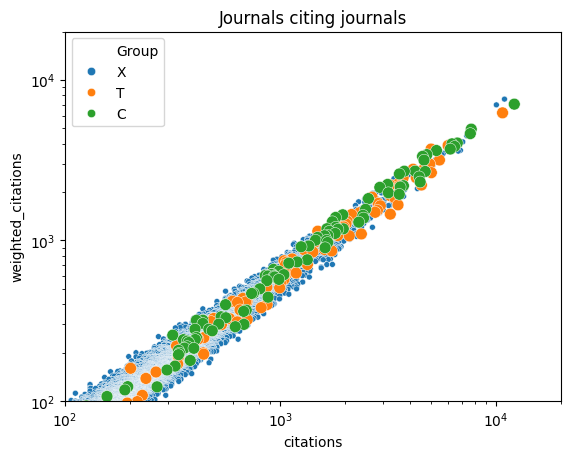

        weighted_citations  citations                         author_id       author_name  reputation %
121358           37.910346        112  https://openalex.org/A5065653856       Yuhta Ishii          99.0
119243           42.889043        131  https://openalex.org/A5072084706  Lee C. Vermeulen          96.0
119244           42.889043        131  https://openalex.org/A5038680388  Marian V. Wrobel          96.0
114970           64.097875        198  https://openalex.org/A5040675847   Maria Polyakova          95.0
121938           34.167026        107  https://openalex.org/A5014890169      Crystal Yang          94.0
114267           67.764455        214  https://openalex.org/A5011119419     Jason Abaluck          93.0
116844           51.592201        163  https://openalex.org/A5035147840   Ignacio Esponda          93.0
112559           85.359999        272  https://openalex.org/A5055141226      Amanda Starc          92.0


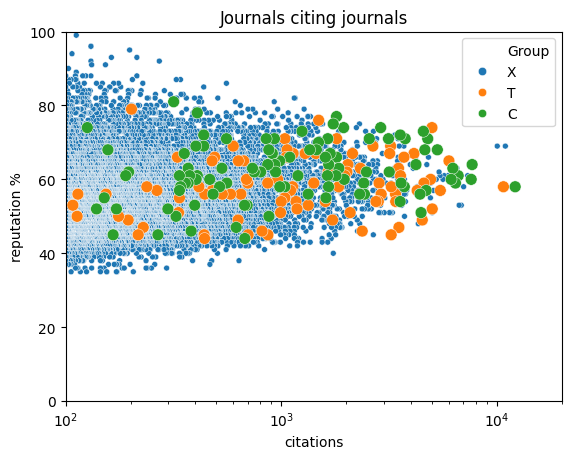

CONSTRUCT GRAPH kind = 'institution'
*** DROP EDGES WITH FEWER THAN 0 CITATIONS df_edges.shape = (3035756, 3)
                           citer_id                          cited_id     weights
0   https://openalex.org/I103737770   https://openalex.org/I103737770  748.846331
1   https://openalex.org/I913958620   https://openalex.org/I913958620  720.387941
2   https://openalex.org/I909854389   https://openalex.org/I909854389  608.180972
3   https://openalex.org/I165932596   https://openalex.org/I165932596  603.474482
4  https://openalex.org/I1321305853  https://openalex.org/I1321305853  594.324130
IGRAPH DN-- 18850 3035756 --
+ attr: name (v), weights (e)
+ edges (vertex names):
                                    edge                                 weights
[0]   https://openalex.org/I103737770->https://openalex.org/I103737770   748.846
[1]   https://openalex.org/I913958620->https://openalex.org/I913958620   720.388
*** SUMMARY OF self.g
None
pageRank
>> CHECK pageRank  - should sum to u

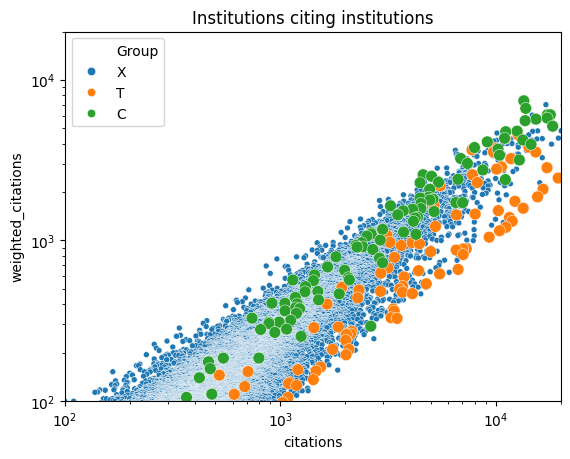

        weighted_citations  citations                         author_id            author_name  reputation %
148132           42.146024        100  https://openalex.org/A5013449882           Peter Conner          99.0
134673           64.226157        167  https://openalex.org/A5009614418  J. Michael Mcwilliams          91.0
145578           42.130409        110  https://openalex.org/A5103342834       Alastair Fischer          90.0
125754           95.191716        260  https://openalex.org/A5113444790             Mary Price          86.0
121601          120.228682        340  https://openalex.org/A5075279889               John Hsu          83.0
139380           47.823490        138  https://openalex.org/A5039639049      Kimberly A. Quaid          82.0
127339           82.028015        239  https://openalex.org/A5019145696     William A Woolston          81.0
138049           49.512174        145  https://openalex.org/A5068260915           Amber Jessup          81.0


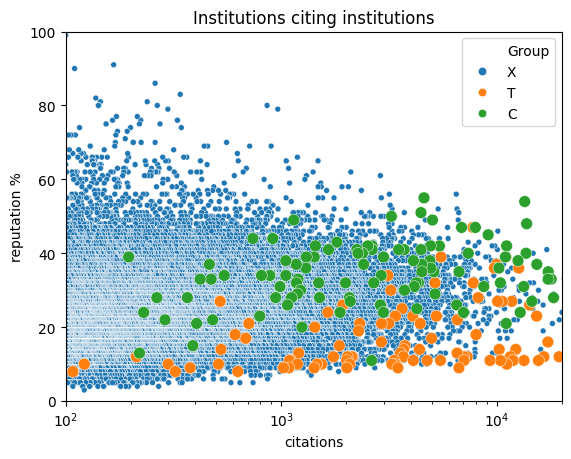

CONSTRUCT GRAPH kind = 'both'
*** DROP EDGES WITH FEWER THAN 0 CITATIONS df_edges.shape = (125900, 3)
                          citer_id                         cited_id  weights
0  https://openalex.org/S175056054  https://openalex.org/S175056054  33531.0
1   https://openalex.org/S94499970   https://openalex.org/S94499970  29356.0
2   https://openalex.org/S94499970  https://openalex.org/S175056054  12544.0
3  https://openalex.org/S173966628  https://openalex.org/S173966628  12122.0
4  https://openalex.org/S136211407  https://openalex.org/S136211407  11169.0
IGRAPH DN-- 1708 125900 --
+ attr: name (v), weights (e)
+ edges (vertex names):
                                    edge                                 weights
[0]   https://openalex.org/S175056054->https://openalex.org/S175056054     33531
[1]   https://openalex.org/S94499970->https://openalex.org/S94499970       29356
*** SUMMARY OF self.g
None
pageRank
>> CHECK pageRank  - should sum to unity sum(ranks) = 1.0
df.shape = (1708, 

In [ ]:
if __name__ == "__main__":
    main()
    print("DONE!")